In [1]:
import torch 
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import models, transforms 

import copy  
import re
import time 
import sys 
import os  
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

from datasets import load_from_disk 
from pathlib import Path 


/mnt/mydata/06.04.2026_home_laptop_backup/jlab-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Bootstrap the root search directly in the notebook to locate and import config
# (This ensures the initial import succeeds even if sys.path isn't configured yet)
current = Path.cwd()
for parent in [current] + list(current.parents):
    if (parent / "README.md").exists():
        if str(parent) not in sys.path:
            sys.path.append(str(parent))
        break

# 2. Perform your clean imports
import config
from src.helpers import *
from src.helpers import apply_train_transform, apply_val_test_transform

# 3. (Optional) Access your paths directly from config
print(config.DATA_DIR)


In [3]:
# Check device 
print(f"--- [CONFIG] Project running on engine: {config.DEVICE} ---")


--- [CONFIG] Project running on engine: cpu ---


In [4]:
# Data already exists in data folder
# Define a directory as a path object (modern pythonic way) 
# Check for a specific "anchor" file to ensure the data is valid. HuggingFace usually contains 'dataset_dict.json'
# Load the data 

data_dir = Path(config.DATA_DIR)   

if not (data_dir / 'dataset_dict.json').exists():  
    raise FileNotFoundError(f"No valid data found at {data_dir}...") 
else: 
    print("Data found") 
    
ds = load_from_disk(data_dir)
print(ds) 
print(type(ds))
print(type(ds['train']))                    
print(type(ds['train'].features))           
print(type(ds['train'].features['label']))  
# print(type(ds['train']['features']))      # Its HUGING FACES DATASET OBJECT, NOT A DICT


Data found
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2300
    })
})
<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Dataset'>
<class 'datasets.features.features.Features'>
<class 'datasets.features.features.ClassLabel'>


In [5]:
# Check data  

classes = ds['train'].features['label'].names
print(f"classes: {classes}")

num_classes = len(classes) 
print(f"num_classes: {num_classes }") 

dataset = ds['train']['image']
print(f"dataset: {dataset[0]}")

labels = ds['train']['label']
print(f"labels: {labels[0]}") 

unique_label_values = np.unique(labels) 
print(f"unique_label_values: {unique_label_values}")  


classes: ['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']
num_classes: 6
dataset: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x7E44E0DAFB80>
labels: 0


unique_label_values: [0 1 2 3 4 5]


In [6]:
# Get min width and min height (to check size compatibility with resnet) 

min_width, min_height = get_min_image_dimensions(ds['train'])
print(f"Min Width: {min_width}, Min Height: {min_height}")


Dataset({
    features: ['image', 'label'],
    num_rows: 2300
})
<class 'datasets.arrow_dataset.Dataset'>


Min Width: 300, Min Height: 225
min image dimension for transfer learning is 225 bec we will keep square images with min dim available


i: 0
First image of this class at index: 0
i: 1


First image of this class at index: 500
i: 2
First image of this class at index: 900
i: 3


First image of this class at index: 1400
i: 4
First image of this class at index: 1700
i: 5


First image of this class at index: 2000


<Figure size 1200x800 with 0 Axes>

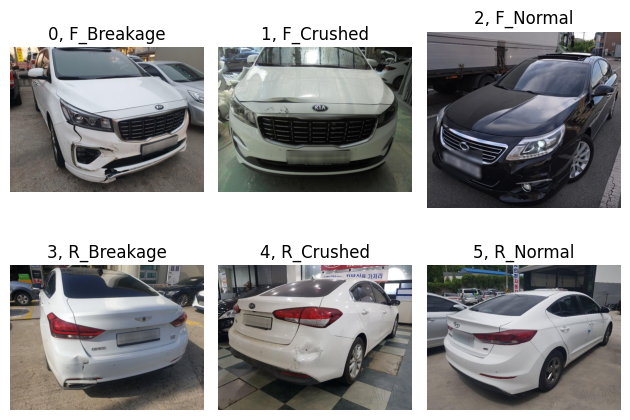

In [7]:
# Visualise the data

plt.figure(figsize=(12,8)) 
fig, axes = plt.subplots(2,3) # 2 rows x 3 cols 

for i, ax in enumerate(axes.flat): 
    print(f"i: {i}")
    
    idx = [j for j,lab in enumerate(labels) if lab==i] # runs 6 times (0-6) as len(axes.flat) is 2x3=6

    if idx != None:
        print(f"First image of this class at index: {idx[0]}")

        ax.imshow(dataset[idx[0]]) 
        ax.set_title(f"{labels[idx[0]]}, {classes[labels[idx[0]]]}") 
        ax.axis('off')

plt.tight_layout() 
plt.show() 


In [8]:
# statified split (all classess will get the same split), 75% for training and 25% for val/test 
# Do this BEFORE APPLYING ANY TRANSFORMATION TO AVOID LEAKAGE

# split full data into train and test 
train_temp = ds['train'].train_test_split( train_size=0.75,
                                           test_size=0.25,
                                           seed=config.RANDOM_SEED,
                                           stratify_by_column='label' )

print(f"train_temp:       {train_temp}")
print(f"type(train_temp): {type(train_temp)}")
print(f"len(train_temp):  {len(train_temp)}")


train_temp:       DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 575
    })
})
type(train_temp): <class 'datasets.dataset_dict.DatasetDict'>
len(train_temp):  2


In [9]:
# split the test into eval and testabs 

val_test = train_temp['test'].train_test_split(    train_size=0.50,
                                                   test_size=0.50,
                                                   seed=config.RANDOM_SEED,
                                                   stratify_by_column='label' )

print(f"val_test:       {val_test}")
print(f"type(val_test): {type(val_test)}")
print(f"len(val_test):  {len(val_test)}")


val_test:       DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 287
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 288
    })
})
type(val_test): <class 'datasets.dataset_dict.DatasetDict'>
len(val_test):  2


In [10]:
# Verify the split counts 

train_ds = train_temp['train'] 
val_ds   = val_test['train'] 
test_ds  = val_test['test'] 

print(f"len of train_ds is {len(train_ds)}")
print(f"len of val_ds is {len(val_ds)}")
print(f"len of test_ds is {len(test_ds)}") 


len of train_ds is 1725
len of val_ds is 287
len of test_ds is 288


In [11]:
# verify class distributions

for split, name in zip([train_ds, val_ds, test_ds], ['train', 'train', 'test']):
    # print(f"name:{name}, \nsplit:{split}")
    print(f"name:{name}")

    labels = split['label'] # get label values
    unique_labels, counts = np.unique(labels, return_counts=True)  # get unique label counts
    # print(unique_labels, counts)
    
    for a, b in zip(unique_labels, counts): 
        print(f"{classes[a]}, {b}") 
                
    print("-"*10)


name:train


F_Breakage, 375
F_Crushed, 300
F_Normal, 375
R_Breakage, 225
R_Crushed, 225
R_Normal, 225
----------
name:train
F_Breakage, 62
F_Crushed, 50
F_Normal, 62
R_Breakage, 38
R_Crushed, 37
R_Normal, 38
----------
name:test
F_Breakage, 63
F_Crushed, 50
F_Normal, 63
R_Breakage, 37
R_Crushed, 38
R_Normal, 37
----------


In [12]:
# MOST critical part : Apply the ttransformation of train, eval/test images seperately  +  convert to tensor

train_ds = train_ds.with_transform(apply_train_transform)
val_ds   = val_ds.with_transform(apply_val_test_transform)
test_ds  = test_ds.with_transform(apply_val_test_transform)

# Verify one batch
print(train_ds[0]['image'].shape) # Should show torch.Size([3, 224, 224]) 
print(val_ds[0]['image'].shape)   # Should show torch.Size([3, 224, 224])  
print(test_ds[0]['image'].shape)  # Should show torch.Size([3, 224, 224]) 


torch.Size([3, 224, 224])


torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


In [13]:
# Create DataLoader with batch size 32 

train_loader = DataLoader( train_ds, batch_size=config.BATCH_SIZE, shuffle=True) # only shuffle the train data
val_loader   = DataLoader( val_ds,   batch_size=config.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader( test_ds,  batch_size=config.BATCH_SIZE, shuffle=False) 


In [14]:
# HF dataset return batches as dictionaries {'image': tensor, 'label': tensor} , not as tuples as in out previous project 
# we used to do,
# img, lbl in trainloder: -> this needs to change 

for batch in train_loader: 
    images, labels = batch['image'], batch['label'] # get images and labels 
    print(f"images.shape:  {images.shape}") 
    print(f"labels.shape:  {labels.shape}")
    break 

print(images[0].shape, labels[0]) # one image and its label in tensor format
print(type(images[0]), type(labels[0])) 


images.shape:  torch.Size([32, 3, 224, 224])
labels.shape:  torch.Size([32])
torch.Size([3, 224, 224]) tensor(0)
<class 'torch.Tensor'> <class 'torch.Tensor'>


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


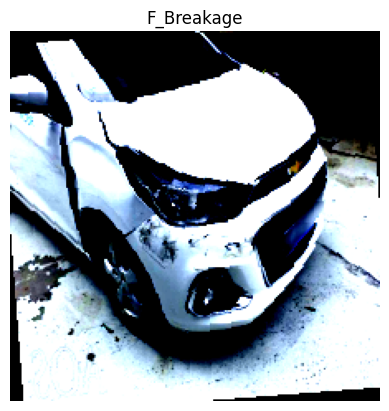

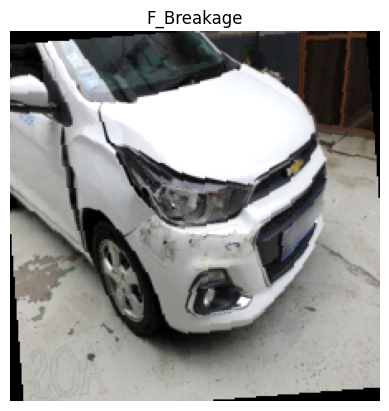

In [15]:
# show image 
plt.imshow( images[0].permute([1,2,0]) ) # change img dim for plt.imshow() from [3,224,224] -> [224,224,3]
plt.title( classes[labels[0]] )
plt.axis('off')
plt.show()

# since the img was transformed using imagenet mean/std values, show the un-transformed image
mean = torch.tensor( imagenet_mean ) # bec images[0] is a tensor!
std  = torch.tensor( imagenet_std )  # bec images[0] is a tensor! 

img = images[0].permute(1, 2, 0)
img = (img*std + mean).clamp(0, 1)
plt.imshow( img )
plt.title( classes[labels[0]] )
plt.axis('off')
plt.show()


### Now the transfer learning part starts - Mobilenet 

In [16]:
# find the resnet model in models folder 

model_dir  = Path(config.MODEL_DIR) 

if not (model_dir / 'mobilenet_v3_small-047dcff4.pth').exists():  
    raise FileNotFoundError(f"No valid resnet model found at {model_dir}...")  
else:
    print('model found')


model found


In [17]:
# load the pre-trained mobilenet_v3_small model (11 CNN layers + 1 FCN)

# load teh model with random weights 
model      = models.mobilenet_v3_small(weights=None)

# Unpacks the .pth file from the disk into a standard Python dictionary of tensors.
state_dict = torch.load(model_dir / 'mobilenet_v3_small-047dcff4.pth', map_location=config.DEVICE)

# Copies those unpacked tensors directly into the matching layers of the model architecture.
model.load_state_dict(state_dict)  

print(model)  
      

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [18]:
# Freeze EVERYTHING first
for param in model.parameters():
    param.requires_grad = False

In [19]:
# replace the last FCN with our network param
# input features: remain the same 
# output classess: change 1000 -> 6 

print(f" model.classifier                   : {model.classifier } ") 
print(f" model.classifier[3].in_features    : {model.classifier[3].in_features} ")  
print(f" model.classifier[3].out_features   : {model.classifier[3].out_features} ")  
print("------")

in_features         = model.classifier[3].in_features
out_features        = num_classes 

# redesign the complete head
model.classifier = nn.Sequential(
    nn.Linear(in_features=576, out_features=1024, bias=True),
    nn.Hardswish(),
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1024, out_features=out_features, bias=True)
  )

print(model.classifier) # new model with our new FCN 


 model.classifier                   : Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=1000, bias=True)
) 
 model.classifier[3].in_features    : 1024 
 model.classifier[3].out_features   : 1000 
------
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=6, bias=True)
)


In [20]:
# Define loss fn or criteria
loss_fn = nn.CrossEntropyLoss()

# Define ADAM optimizer
# Train ONLY the head for a few epochs using a standard learning rate
optimizer = optim.Adam( filter( lambda p: p.requires_grad, model.parameters() ), 
                        lr           = config.LEARNING_RATE,     # learning rate         (CAR SPEED)
                        betas        = (0.9,0.999),              # Momentum of gradient  (HOW SMOOTHLY ACC/BRAKE IS APPLIED)
                        weight_decay = 1e-4)                     # L2 regularization     (FRICTION TO PREVENT SKIDDING)

# Define scheduler to update/change learning rate during optimization
scheduler = optim.lr_scheduler.ReduceLROnPlateau( 
    optimizer, 
    mode     = 'min', # Lowers the lr when the validation loss stops decreasing.
    factor   = 0.1,   # Multiplier used to cut the learning rate (e.g., 0.001 -> 0.0001). 
    patience = 3)     # Number of train epochs to wait without improvement, before forcing a lr reduction.


In [21]:
# evauate accuracy on TEST data (seperate from train and val data)

start = time.time()

# Use 2 of 4 cores so that I can do other work side by side. 
torch.set_num_threads(config.SET_NUM_THREADS) 

# --- Capture the returned best weights ---
best_weights = train_model(  model        = model, 
                             epochs       = config.EPOCHS,             
                             train_loader = train_loader,    # TRAIN DATA         
                             val_loader   = val_loader,      # VAL DATA       
                             loss_fn      = loss_fn, 
                             optimizer    = optimizer,
                             scheduler    = scheduler     )            

print(f"Total time taken to execute train_model() is : {(time.time()-start)/60} minutes")

# --- Explicitly reload the best parameters (Epoch 7) into the model ---
if best_weights is not None:
    model.load_state_dict(best_weights)
    print("-> Restored model parameters from the peak validation epoch for testing.")
    
    # --- NEW ADDITION: Save the best weights to the models folder ---
    # Uses the model_dir path defined at the top of the script
    save_file_path = model_dir / 'mobilenet_v3_small_custom_best.pth' 
    torch.save(best_weights, save_file_path)
    print(f"-> Successfully saved the best model weights to: {save_file_path}")
    
print("----------------------------------------------------------------------------") 
# Evaluate accuracy on TEST data (seperate from train and val data)
# This will now correctly execute using the best Epoch 7 parameters instead of Epoch 10.
test_acc, _, y_pred, y_true = val_model(  model      = model,
                                          val_loader = test_loader, # TEST DATA
                                          loss_fn    = loss_fn)
print(f"mobilenet_v3_small Accuracy based on test data is : {test_acc:.2f} %")


---- Epoch [1/20], Batch [1/54], Batch_Loss 1.819 


---- Epoch [1/20], Batch [11/54], Batch_Loss 1.687 


---- Epoch [1/20], Batch [21/54], Batch_Loss 1.251 


---- Epoch [1/20], Batch [31/54], Batch_Loss 1.251 


---- Epoch [1/20], Batch [41/54], Batch_Loss 0.954 


...

---- Epoch [20/20], Batch [31/54], Batch_Loss 0.421 


---- Epoch [20/20], Batch [41/54], Batch_Loss 0.302 


---- Epoch [20/20], Batch [51/54], Batch_Loss 0.436 


Epoch [20/20], Train Loss: 0.414, Val Acc: 70.035%, Val Loss: 0.703, LR: 1.0000000000000002e-06
Total time taken to execute train_model() is : 30.929961256186168 minutes
-> Restored model parameters from the peak validation epoch for testing.
-> Successfully saved the best model weights to: /mnt/mydata/06.04.2026_home_laptop_backup/Downloads/Course3_AI_Bootcamp/Deep_Learning/ch13_Project_Car_Damage_Detection/car-damage-classifier/models/mobilenet_v3_small_custom_best.pth
----------------------------------------------------------------------------


mobilenet_v3_small Accuracy based on test data is : 75.69 %


In [22]:
# Pass the outputs directly into scikit-learn functions
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

report = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
print(report)


              precision    recall  f1-score   support

  F_Breakage       0.75      0.63      0.69        63
   F_Crushed       0.64      0.68      0.66        50
    F_Normal       0.84      0.92      0.88        63
  R_Breakage       0.82      0.76      0.79        37
   R_Crushed       0.66      0.71      0.68        38
    R_Normal       0.82      0.84      0.83        37

    accuracy                           0.76       288
   macro avg       0.76      0.76      0.75       288
weighted avg       0.76      0.76      0.76       288



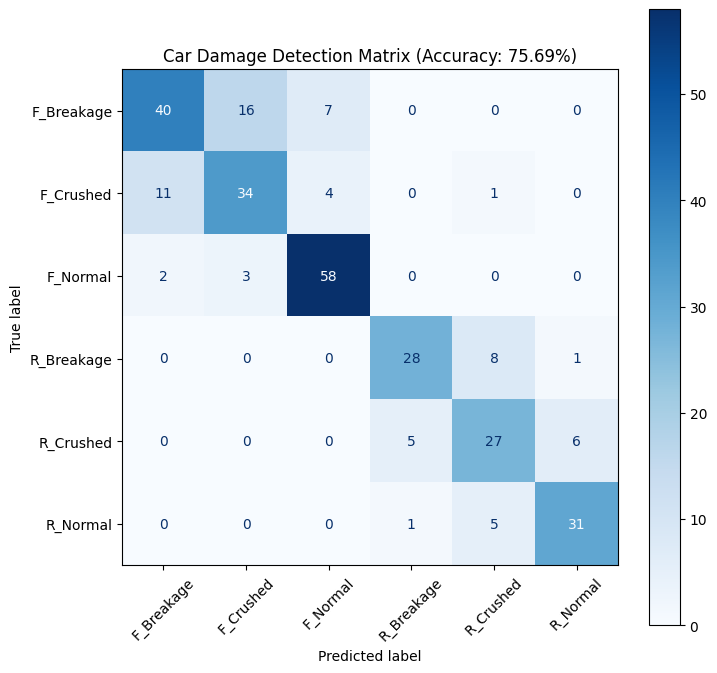

In [23]:
# confusion matrix 
cm = confusion_matrix(y_true, y_pred)

# Initialize and customize the visual display container
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=classes
)

# Plot the matrix onto a standard matplotlib canvas
fig, ax = plt.subplots(figsize=(8, 8)) # Give it an 8x8 inch canvas size for legibility
disp.plot(
    include_values=True,    # Show numerical counts inside each box
    cmap='Blues',           # Classic clean blue shading gradient
    ax=ax,                  # Bind it to our customized canvas size
    xticks_rotation=45      # Rotates labels by 45 degrees so they do not overlap
)

plt.title(f'Car Damage Detection Matrix (Accuracy: {test_acc:.2f}%)')
plt.show()

In [24]:
# Version 2 of the project will include unfreezing the last CNN + classifier layer for re-training to increase the accuracy further